Recurrent Neural Network (RNN) — Time Series Forecasting

In [1]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


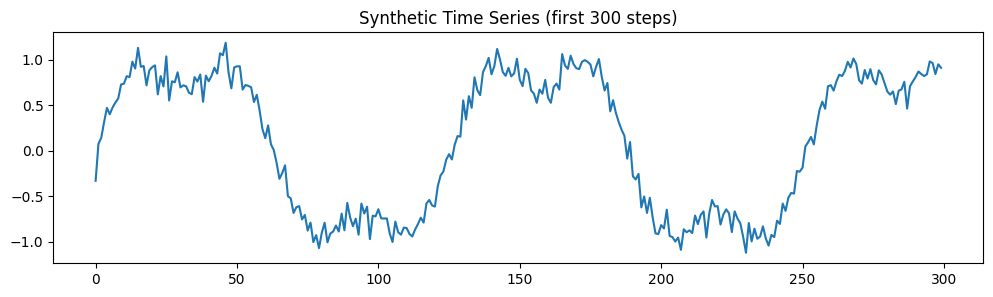

In [2]:
# CELL 2 — Generate synthetic time series (noisy sine wave — classic RNN sanity-check task)
def generate_series(length=2000):
    t = np.arange(length)
    series = np.sin(0.05 * t) + 0.3 * np.sin(0.15 * t) + 0.1 * np.random.randn(length)
    return series.astype(np.float32)

series = generate_series()

plt.figure(figsize=(12, 3))
plt.plot(series[:300])
plt.title("Synthetic Time Series (first 300 steps)")
plt.show()

In [3]:
# CELL 3 — Create windowed sequences for next-step prediction
SEQ_LEN = 30

def make_windows(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X, y = make_windows(series, SEQ_LEN)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Shape: [batch, seq_len, 1] — RNN expects a feature dimension even for univariate series
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1).to(device)

print(X_train_t.shape, y_train_t.shape)

torch.Size([1576, 30, 1]) torch.Size([1576, 1])


In [4]:
# CELL 4 — Model definition (vanilla RNN)
class TimeSeriesRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=1):
        super().__init__()
        # nn.RNN uses tanh by default — the classic recurrent activation,
        # bounding hidden state values but prone to vanishing gradients over long sequences
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        output, hidden = self.rnn(x)          # output: [batch, seq_len, hidden_dim]
        last_output = output[:, -1, :]         # take final time step's hidden state
        return self.fc(last_output)            # linear output — continuous value prediction

model = TimeSeriesRNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

TimeSeriesRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [5]:
# CELL 5 — Training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {loss.item():.6f}")

Epoch 10/100 — Loss: 0.036929
Epoch 20/100 — Loss: 0.031608
Epoch 30/100 — Loss: 0.019435
Epoch 40/100 — Loss: 0.019503
Epoch 50/100 — Loss: 0.018227
Epoch 60/100 — Loss: 0.017167
Epoch 70/100 — Loss: 0.016489
Epoch 80/100 — Loss: 0.015895
Epoch 90/100 — Loss: 0.015633
Epoch 100/100 — Loss: 0.015507


In [6]:
# CELL 6 — Evaluation
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    mse = criterion(test_preds, y_test_t).item()
    print(f"Test MSE: {mse:.6f}")

Test MSE: 0.015621


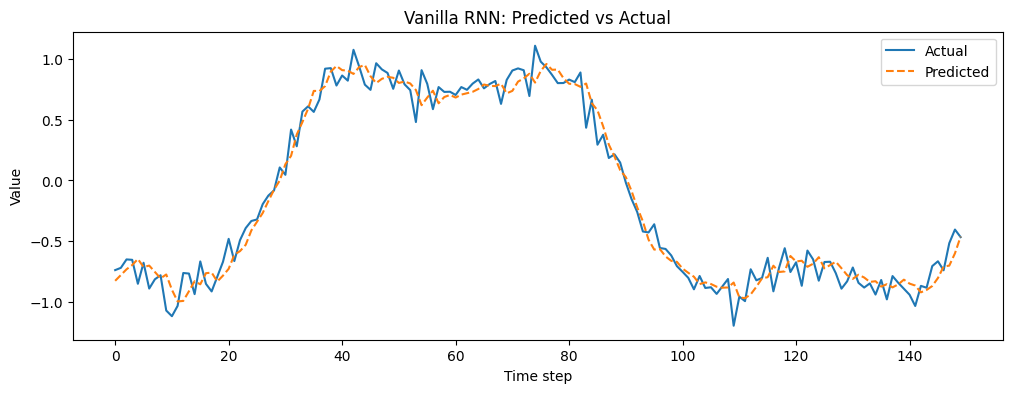

In [7]:
# CELL 7 — Plot predictions vs actual
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).cpu().numpy().flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_test[:150], label="Actual")
plt.plot(test_preds[:150], label="Predicted", linestyle="--")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Vanilla RNN: Predicted vs Actual")
plt.legend()
plt.show()

In [8]:
# CELL 8 — Demonstrate vanishing gradients: longer sequences degrade vanilla RNN performance
def train_and_eval_with_seq_len(seq_len, epochs=60):
    X, y = make_windows(series, seq_len)
    split = int(0.8 * len(X))
    X_tr = torch.tensor(X[:split], dtype=torch.float32).unsqueeze(-1).to(device)
    y_tr = torch.tensor(y[:split], dtype=torch.float32).unsqueeze(-1).to(device)
    X_te = torch.tensor(X[split:], dtype=torch.float32).unsqueeze(-1).to(device)
    y_te = torch.tensor(y[split:], dtype=torch.float32).unsqueeze(-1).to(device)

    m = TimeSeriesRNN().to(device)
    opt = optim.Adam(m.parameters(), lr=0.01)
    crit = nn.MSELoss()

    for _ in range(epochs):
        m.train()
        opt.zero_grad()
        loss = crit(m(X_tr), y_tr)
        loss.backward()
        opt.step()

    m.eval()
    with torch.no_grad():
        test_mse = crit(m(X_te), y_te).item()
    return test_mse

for seq_len in [10, 30, 60, 100]:
    mse = train_and_eval_with_seq_len(seq_len)
    print(f"Sequence length {seq_len}: Test MSE = {mse:.6f}")

print("\nAs sequence length grows, vanilla RNNs typically struggle more —")
print("this is the motivation for gated architectures like LSTM and GRU.")

Sequence length 10: Test MSE = 0.018090
Sequence length 30: Test MSE = 0.016291
Sequence length 60: Test MSE = 0.017042
Sequence length 100: Test MSE = 0.016086

As sequence length grows, vanilla RNNs typically struggle more —
this is the motivation for gated architectures like LSTM and GRU.
